In [85]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
import asyncio


console = Console()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [86]:
class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description = "A list of tasks to be executed.")

In [87]:
class graph_schema(BaseModel):
    tasks: List[str] = Field(..., description = "A list of tasks to be executed.")
    results: List[str] = Field(..., description = "A list of results after the tasks have been executed")
    query: str
    summary: str

In [88]:
def orchestrator(state: graph_schema) -> graph_schema:
    user_query = state.query
    parser = PydanticOutputParser(pydantic_object=llm_schema)
    prompt = f"""
    You are a helpful assistant. You divide user query into a list of tasks and return the result in 
    a specified format.

    The user query: {user_query}

    {parser.get_format_instructions()}
    """
    response = llm.invoke(prompt)
    parsed = parser.parse(response.content)
    state.tasks = parsed.tasks
    return state

In [68]:
show(orchestrator(graph_schema(
    query = "What is the capital of India and USA?",
    tasks = [],
    results = [],
    summary = ""
)))

╭──────────────────────────── 🤖 LLM Response ────────────────────────────╮
│ graph_schema(                                                           │
│     tasks=[                                                             │
│         'Find the capital of India',                                    │
│         'Find the capital of the USA'                                   │
│     ],                                                                  │
│     results=[],                                                         │
│     query='What is the capital of India and USA?',                      │
│     summary=''                                                          │
│ )                                                                       │
╰─────────────────────────────────────────────────────────────────────────╯

In [89]:
async def execute(task: str) -> str:
    response = await llm.ainvoke(f"Please perform this task:\n\n{task}")
    return response.content

In [90]:
async def worker(state: graph_schema) -> graph_schema:
    tasks = state.tasks
    results = await asyncio.gather(*(execute(t) for t in tasks))
    state.results = results
    return state

In [91]:
response = orchestrator(graph_schema(
    query = "What is the capital of India and USA?",
    tasks = [],
    results = [],
    summary = ""
))

In [92]:
show(response)

╭────────────────────────────── 🤖 LLM Response ──────────────────────────────╮
│ graph_schema(                                                               │
│     tasks=[                                                                 │
│         'What is the capital of India?',                                    │
│         'What is the capital of USA?'                                       │
│     ],                                                                      │
│     results=[],                                                             │
│     query='What is the capital of India and USA?',                          │
│     summary=''                                                              │
│ )                                                                           │
╰─────────────────────────────────────────────────────────────────────────────╯

In [93]:
response1 = await worker(response)

In [94]:
show(response1)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ graph_schema(                                                                                                   │
│     tasks=['What is the capital of India?', 'What is the capital of USA?'],                                     │
│     results=[                                                                                                   │
│         'The capital of India is **New Delhi**.',                                                               │
│         'The capital of the United States of America is **Washington, D.C.** (Washington, District of           │
│ Columbia).\n\nIt has been the federal capital since 1800, established by the U.S. Constitution as a separate    │
│ federal district, not part of any state.'                                                                       │
│     ],                                                                                                          │
│     query='What is the capital of India and USA?',                                                              │
│     summary=''                                                                                                  │
│ )                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [100]:
def collector(state: graph_schema) -> graph_schema:
    user_query = state.query
    results = state.results
    prompt = f"""
    You are a helpful assistant. You are having a list of results returned by the worker for the
    query asked by a user. You have to summarize all the results in a concise manner.
    The user query:

    {user_query}

    Results:

    {results}
    """
    response = llm.invoke(prompt).content
    state.summary = response
    return state

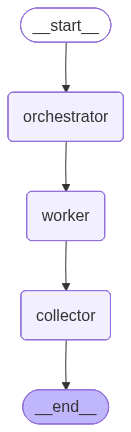

In [101]:
graph = StateGraph(graph_schema)

graph.add_node('orchestrator', orchestrator)
graph.add_node('worker', worker)
graph.add_node('collector', collector)

graph.add_edge(START, 'orchestrator')
graph.add_edge('orchestrator', 'worker')
graph.add_edge('worker', 'collector')
graph.add_edge('collector', END)

task_graph = graph.compile()

from IPython.display import Image, display
Image(post_graph.get_graph().draw_mermaid_png())

In [103]:
show(await task_graph.ainvoke(graph_schema(
    query = "What is the capital of India and USA?",
    tasks = [],
    results = [],
    summary = ""
)))

╭───────────────────────────────────────── 🤖 LLM Response ─────────────────────────────────────────╮
│ {                                                                                                 │
│     'tasks': ['What is the capital of India?', 'What is the capital of USA?'],                    │
│     'results': [                                                                                  │
│         'The capital of India is New Delhi.',                                                     │
│         'The capital of the United States of America (USA) is Washington, D.C.'                   │
│     ],                                                                                            │
│     'query': 'What is the capital of India and USA?',                                             │
│     'summary': 'The capital of India is New Delhi and the capital of the USA is Washington, D.C.' │
│ }                                                                                                 │
╰───────────────────────────────────────────────────────────────────────────────────────────────────╯